In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df= pd.read_csv("MSFT.csv", index_col="Date", parse_dates=True)

close_data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

train_size = int(len(scaled_data) * 0.9)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]  # include last 60 train days for first test sequence

In [2]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [3]:
X_train, y_train = create_sequences(train_data)
X_test, y_test = create_sequences(test_data)

In [4]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(1068, 60, 1) (126, 60, 1)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0304 - val_loss: 0.0020
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0030 - val_loss: 0.0019
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0030 - val_loss: 0.0044
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0027 - val_loss: 0.0035
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0029 - val_loss: 0.0053
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0

In [7]:
predictions = model.predict(X_test)
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step


In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lstm= np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
print(rmse_lstm)

22.158044516743036


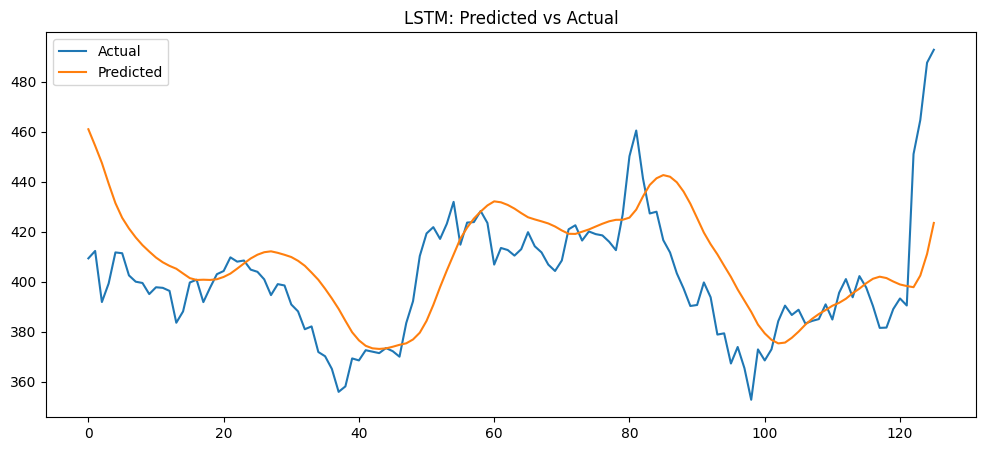

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions_actual, label="Predicted")
plt.legend()
plt.title("LSTM: Predicted vs Actual")
plt.show()

In [10]:
model.save("lstm_model.h5")

In [13]:
import json

with open("lstm_result.json", "w") as f:
    json.dump({"LSTM RMSE" : rmse_lstm}, f)